In [11]:
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [12]:
def plot_bar_chart(df, x, hue, title, facet=None, stacked_by=None):
    plt.figure(figsize=(10,6))
    
    if stacked_by:
        # group and pivot for stacked bar chart (use mean for percentages)
        if facet:
            pivot_df = df.groupby([x, hue, facet])['value'].mean().reset_index()
            for fac in df[facet].unique():
                sub = pivot_df[pivot_df[facet] == fac]
                pivot = sub.pivot(index=x, columns=hue, values='value').fillna(0)
                ax = pivot.plot(kind='bar', stacked=True, ax=plt.gca())
                plt.legend(title=stacked_by)
                # add labels to each bar segment
                for cidx, col in enumerate(pivot_df.columns):
                    for ridx, val in enumerate(pivot_df[col]):
                        if val > 0:
                            bottom = pivot_df.iloc[ridx, :cidx].sum()
                            ax.text(ridx, bottom + val/2, f"{val:.1f}", ha='center', va='center', fontsize=9, color="white" if val > 5 else "black")
        else: 
            pivot_df = df.groupby([x, hue])['value'].mean().unstack(fill_value=0)
            ax = pivot_df.plot(kind='bar', stacked=True, ax=plt.gca())
            plt.legend(title=stacked_by)
            # add labels to each bar segment
            for cidx, col in enumerate(pivot_df.columns):
                for ridx, val in enumerate(pivot_df[col]):
                    if val > 0:
                        bottom = pivot_df.iloc[ridx, :cidx].sum()
                        ax.text(ridx, bottom + val/2, f"{val:.1f}", ha='center', va='center', fontsize=9, color="white" if val > 5 else "black")
    else:
        # Regular bar chart
        if facet:
            agg_df = df.groupby([x, hue, facet])['value'].mean().reset_index()
            ax = sns.catplot(data=agg_df, x=x, y='value', hue=hue, col=facet, kind='bar', height=5, aspect=1.2)
            ax.set_titles(col_template="{col_name}")

            # add labels on bars
            for ax_i in ax.axes.flatten():
                ax_i.set_ylabel('Average Percentage')
                for container in ax_i.containers:
                    ax_i.bar_label(container, fmt='%.1f', padding=2)
                    
            plt.subplots_adjust(top=0.85)
            plt.suptitle(title)

        else:
            agg_df = df.groupby([x, hue])['value'].mean().reset_index()
            ax = sns.barplot(data=agg_df, x=x, y='value', hue=hue)

            # add labels on bars
            for container in ax.containers:
                ax.bar_label(container, fmt='%.1f', padding=2)
    
            plt.title(title)
            plt.xlabel(x)
            plt.ylabel('Average Percentage')
            plt.tight_layout()
            plt.show()

In [13]:
# Load the Parquet file
df = pq.read_table('../../data/health-indicators/health_indicator24.parquet').to_pandas()

In [14]:
df.head()

,ref_date,geo,age_group,gender,indigenous_identity,indicators,characteristics,value,life_stress,social_wellbeing,smoking_status,perceived_mental_health_status,chronic_health_condition_count,chronic/physical_health_condition,perceived_health_status,bmi_category,healthcare_access,alcohol_use
0,2015/2018,Canada,"Total, 18 years and over",Both sexes,"Total, Indigenous identity","Perceived health, very good or excellent",Percent,49.6,None,None,None,None,None,None,"Perceived health, very good or excellent",None,None,None
1,2015/2018,Canada,"Total, 18 years and over",Both sexes,"Total, Indigenous identity","Perceived health, good",Percent,32.1,None,None,None,None,None,None,"Perceived health, good",None,None,None
2,2015/2018,Canada,"Total, 18 years and over",Both sexes,"Total, Indigenous identity","Perceived health, fair or poor",Percent,18.3,None,None,None,None,None,None,"Perceived health, fair or poor",None,None,None
3,2015/2018,Canada,"Total, 18 years and over",Both sexes,"Total, Indigenous identity","Perceived mental health, very good or excellent",Percent,59.4,None,None,None,"Perceived mental health, very good or excellent",None,None,None,None,None,None
4,2015/2018,Canada,"Total, 18 years and over",Both sexes,"Total, Indigenous identity","Perceived mental health, good",Percent,27.8,None,None,None,"Perceived mental health, good",None,None,None,None,None,None


# Chronic Health Condition Count

<Figure size 1000x600 with 0 Axes>

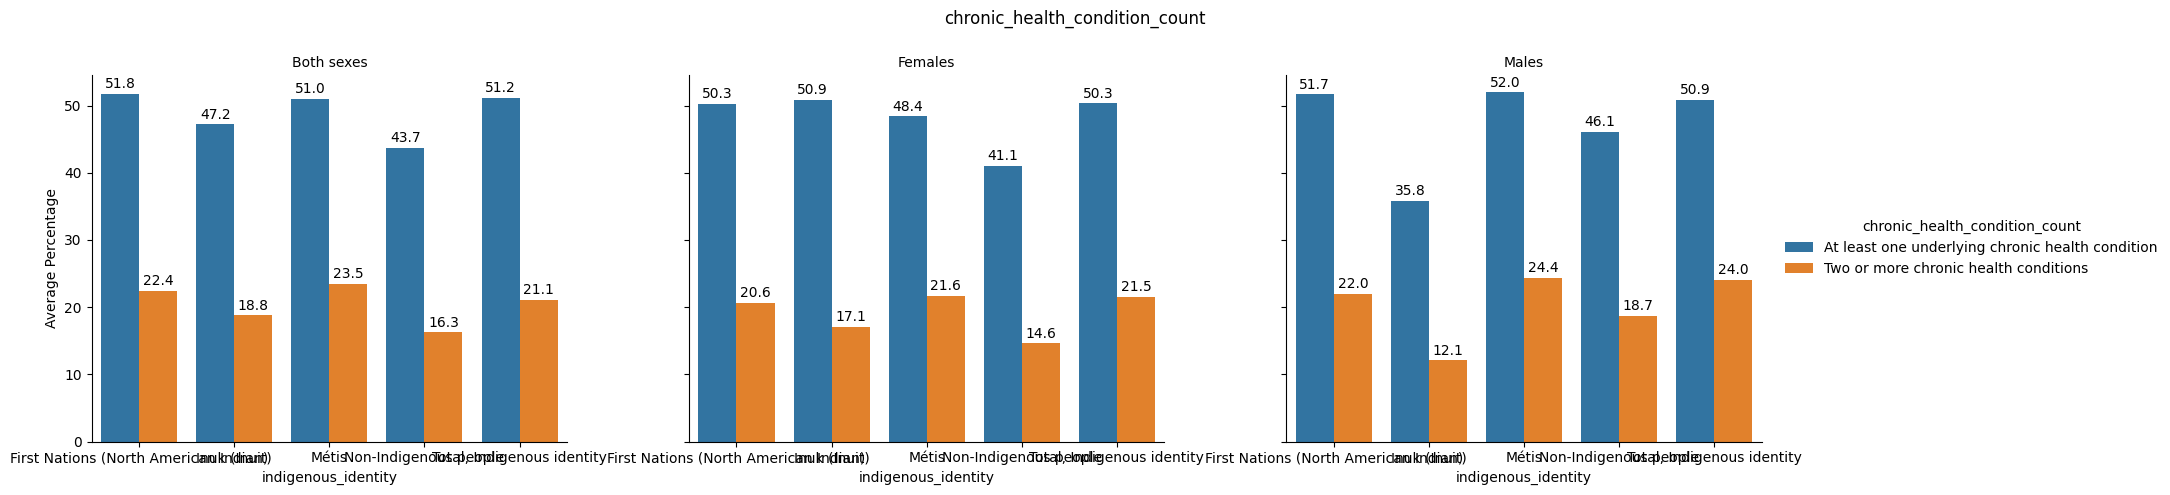

In [15]:
plot_bar_chart(df, 'indigenous_identity', 'chronic_health_condition_count', "chronic_health_condition_count", 'gender', stacked_by=False)

<Figure size 1000x600 with 0 Axes>

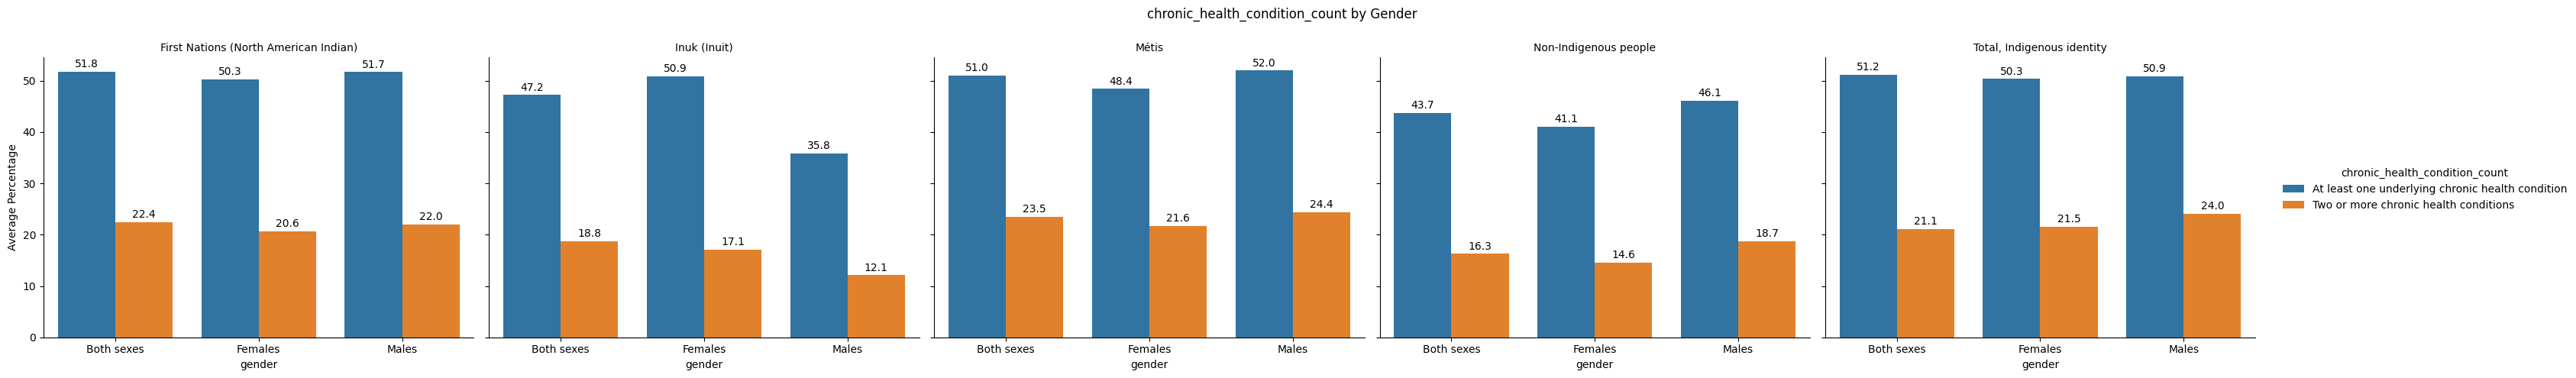

In [16]:
plot_bar_chart(df, 'gender', 'chronic_health_condition_count', "chronic_health_condition_count by Gender", 'indigenous_identity', stacked_by=False)

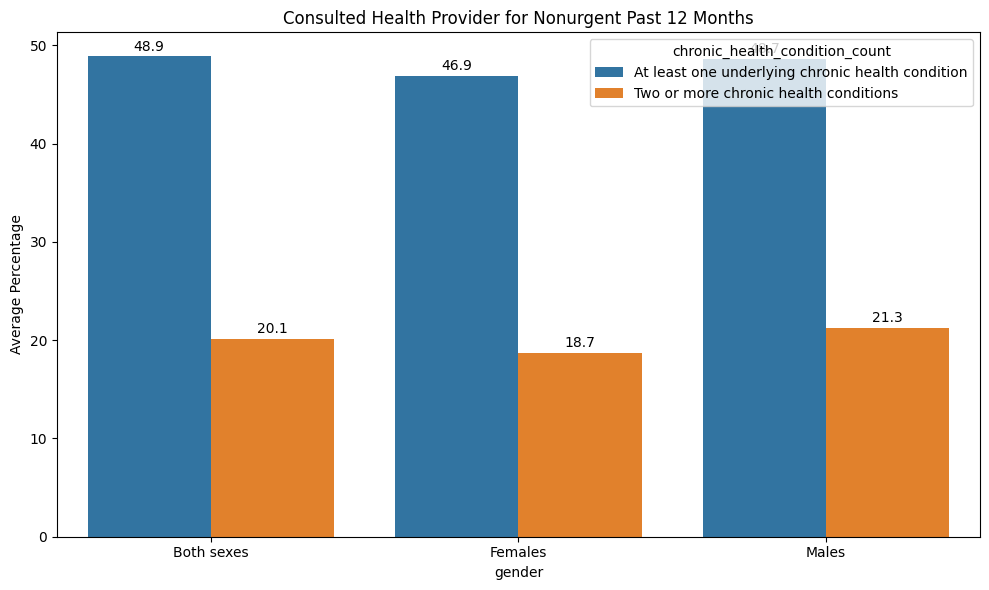

In [17]:
plot_bar_chart(df, 'gender', 'chronic_health_condition_count', "Consulted Health Provider for Nonurgent Past 12 Months", stacked_by=False)

# BMI Category

In [18]:
df.columns

Index(['ref_date', 'geo', 'age_group', 'gender', 'indigenous_identity',
       'indicators', 'characteristics', 'value', 'life_stress',
       'social_wellbeing', 'smoking_status', 'perceived_mental_health_status',
       'chronic_health_condition_count', 'chronic/physical_health_condition',
       'perceived_health_status', 'bmi_category', 'healthcare_access',
       'alcohol_use'],
      dtype='object')

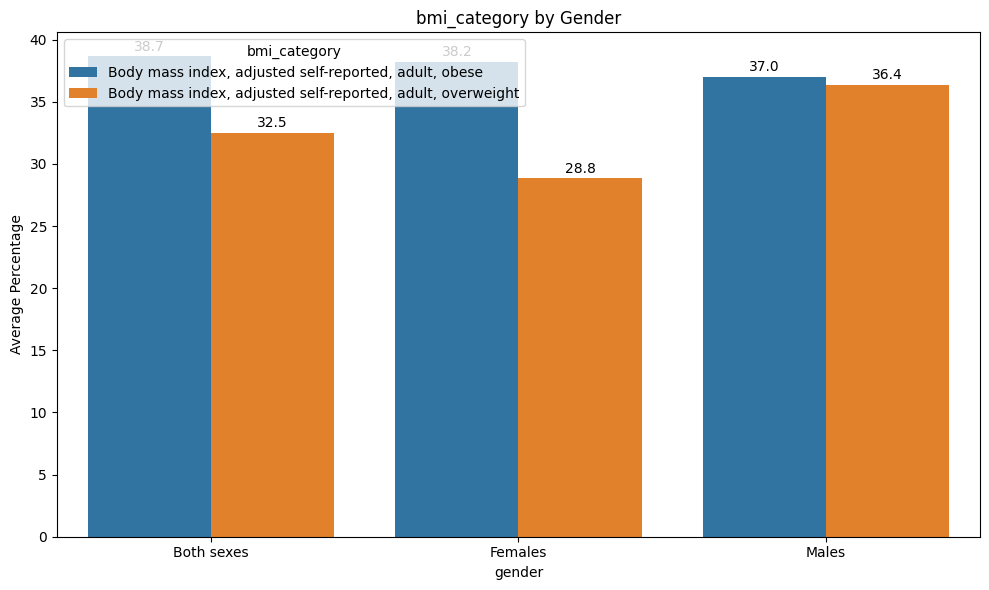

In [19]:
plot_bar_chart(df, 'gender', 'bmi_category', "bmi_category by Gender", stacked_by=False)

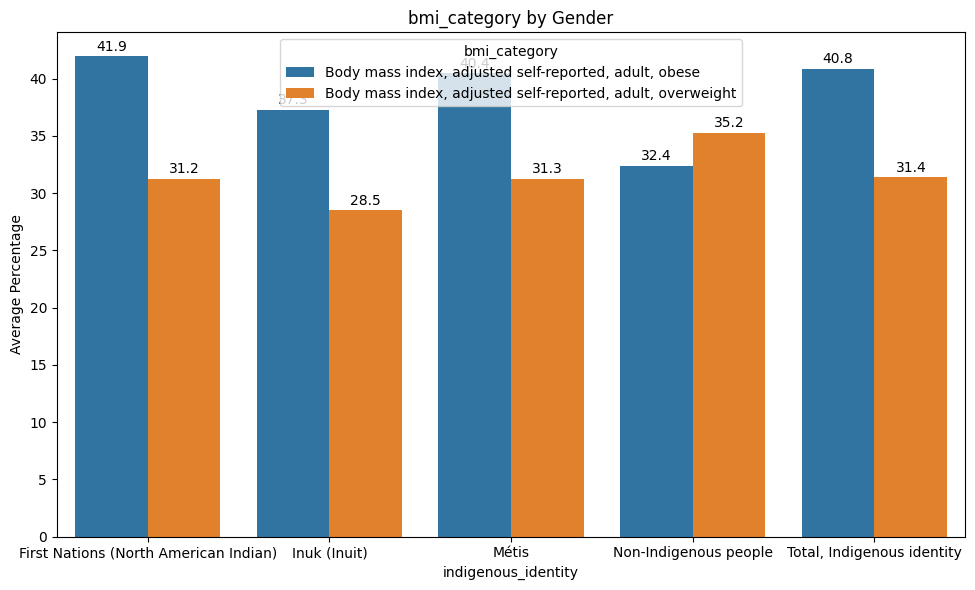

In [20]:
plot_bar_chart(df, 'indigenous_identity', 'bmi_category', "bmi_category by Gender", stacked_by=False)

# Other Health Indicators

In [21]:
plot_cols = ['chronic/physical_health_condition', 'healthcare_access',
       'smoking_status', 'life_stress', 'perceived_health_status',
       'social_wellbeing', 'alcohol_use', 'perceived_mental_health_status']

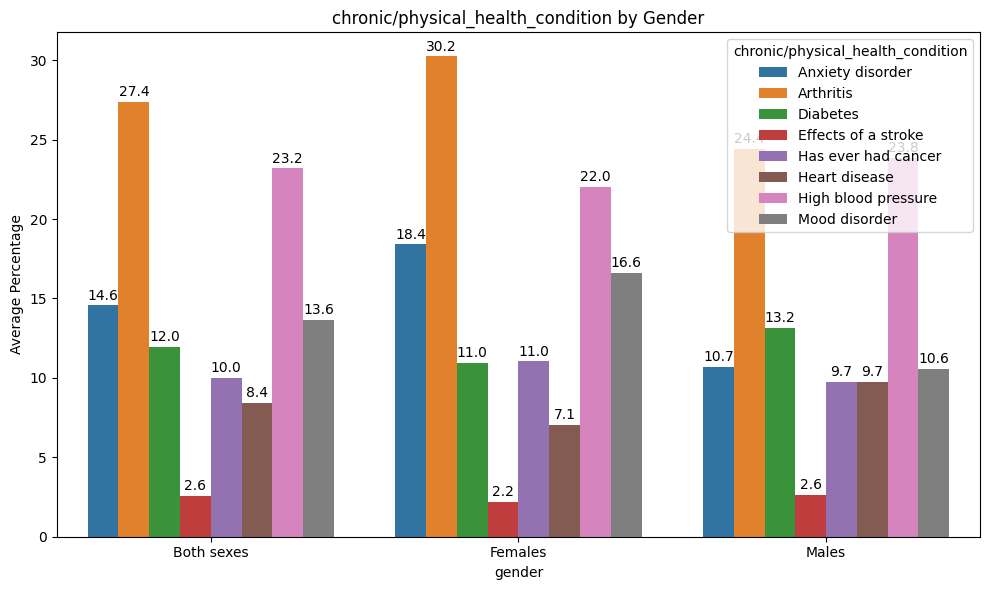

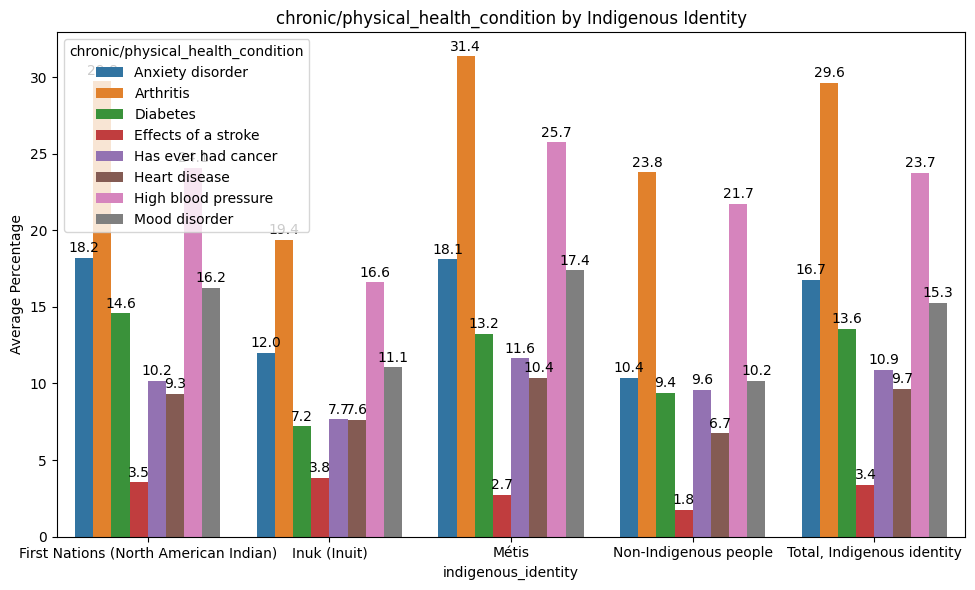

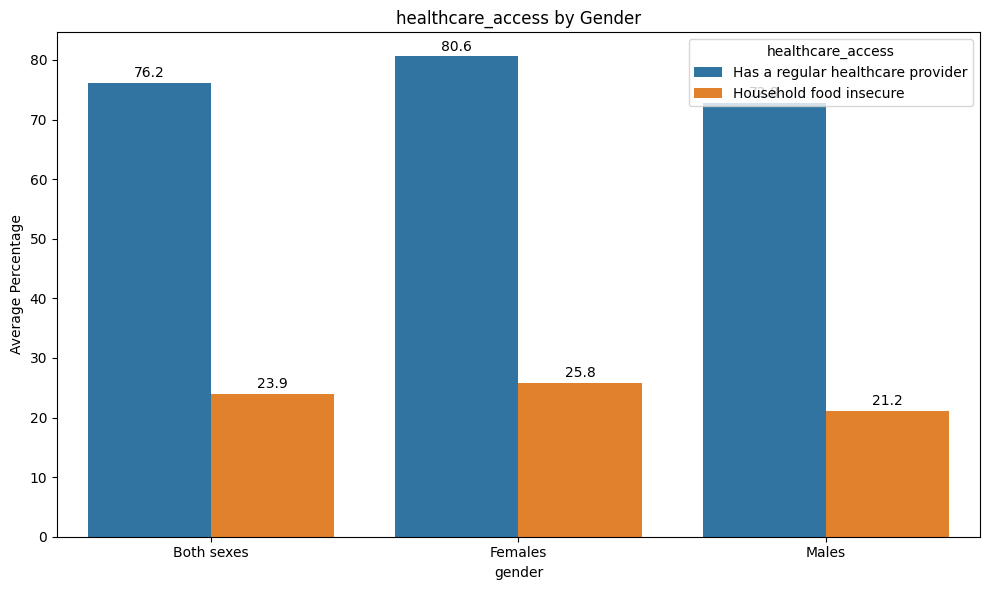

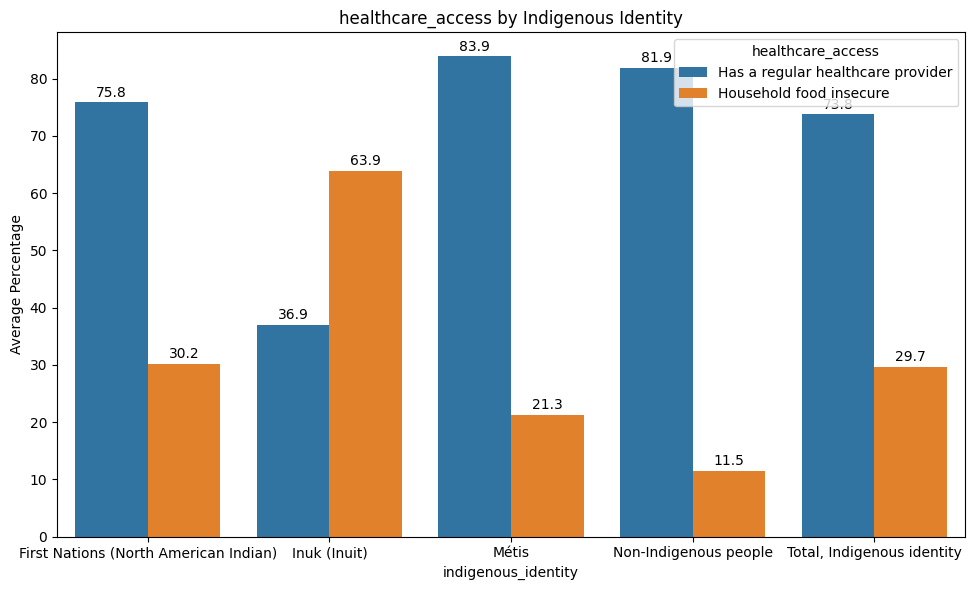

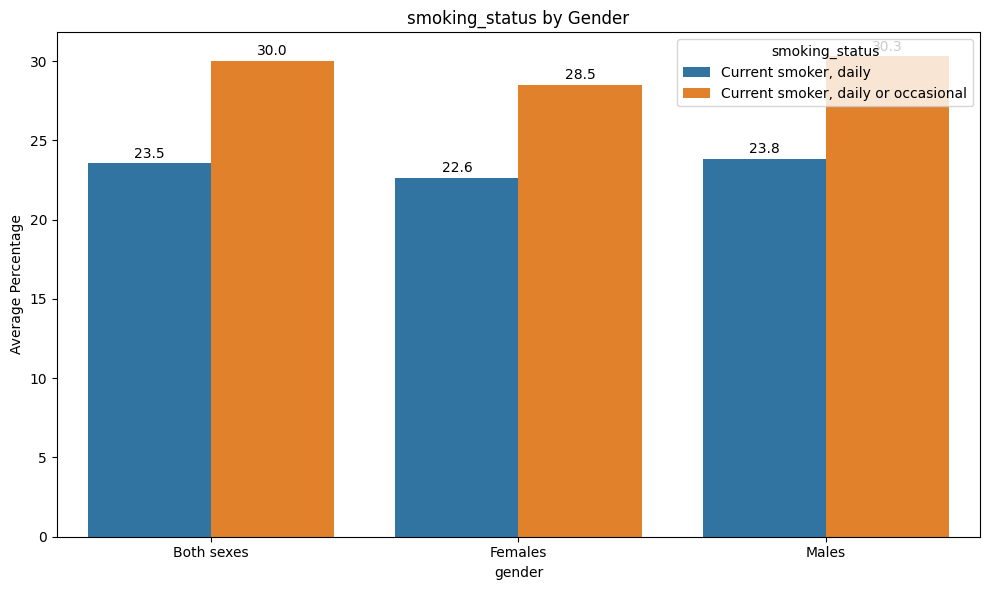

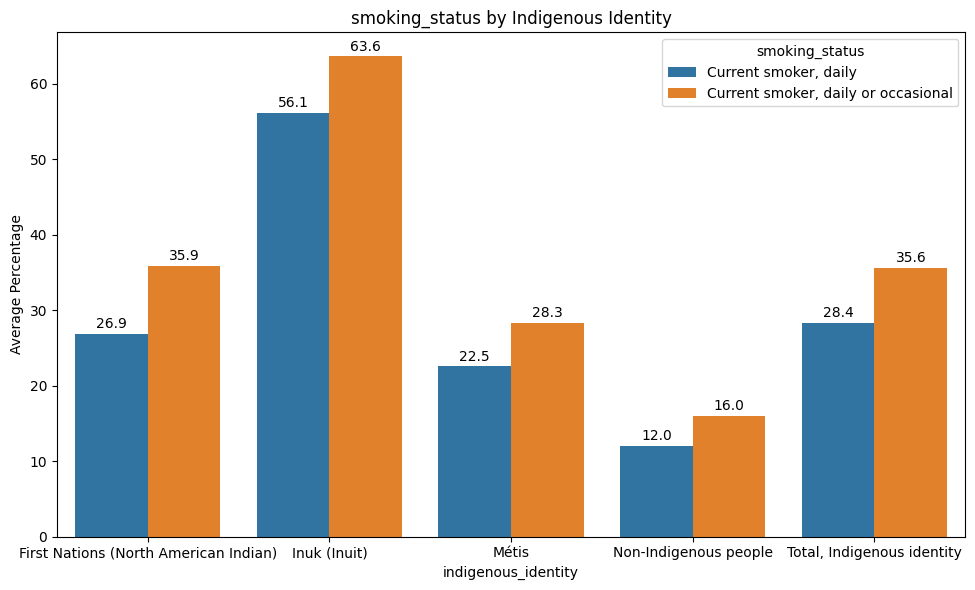

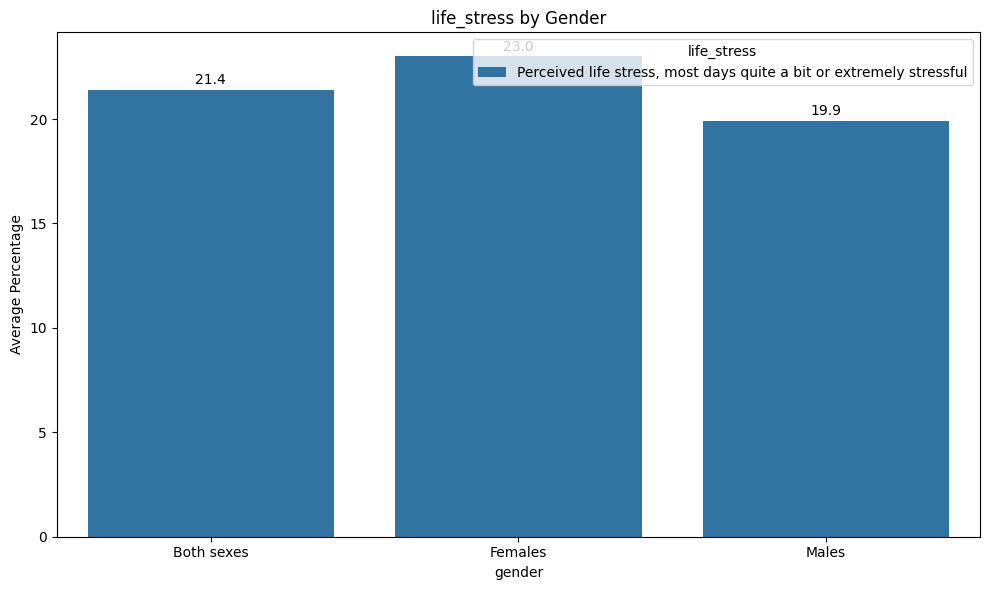

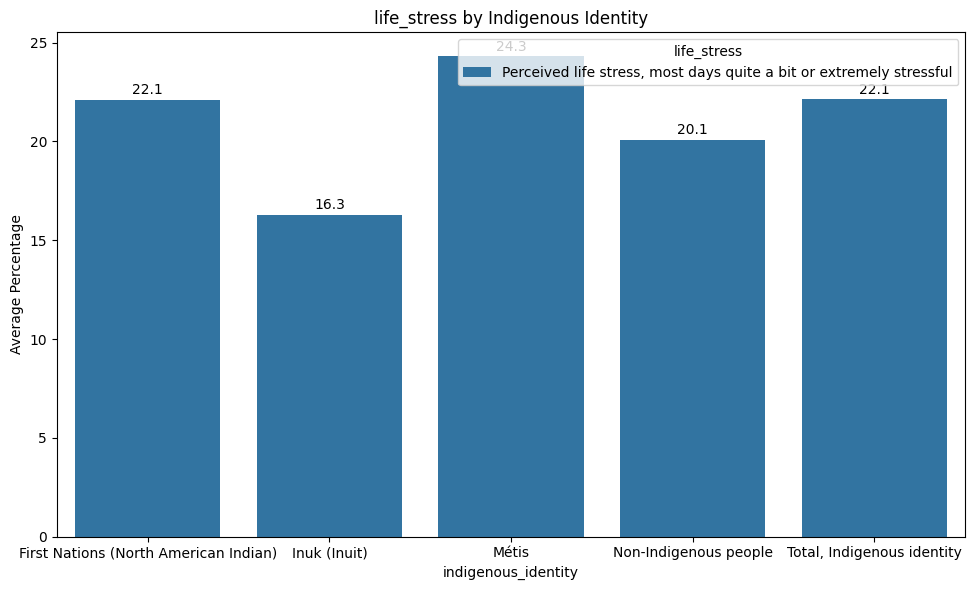

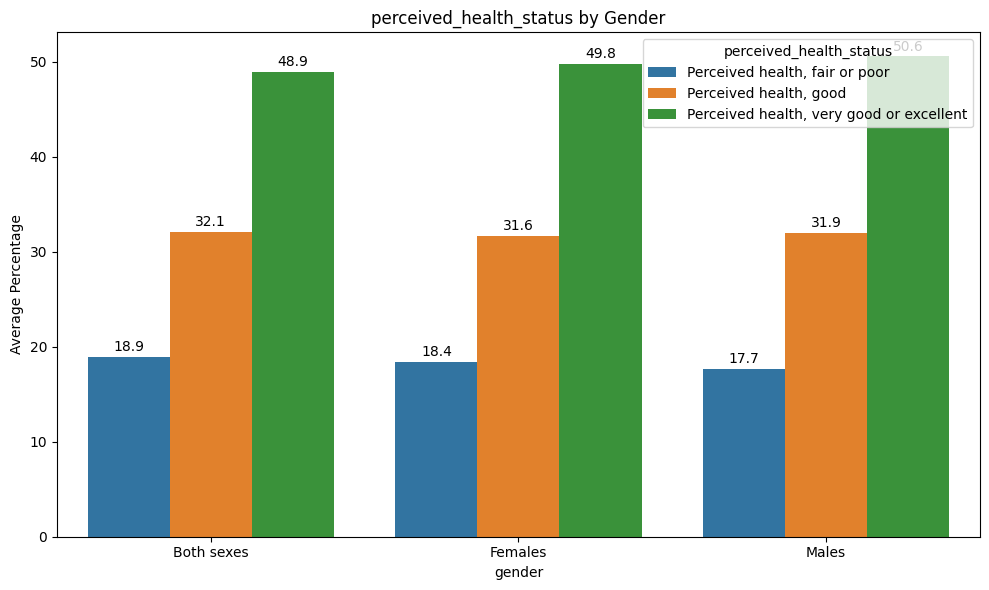

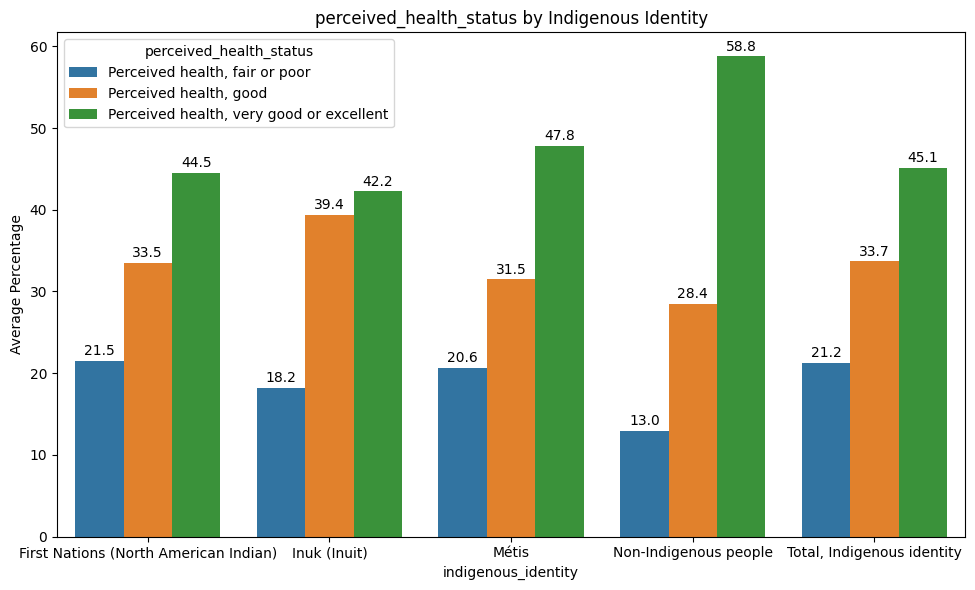

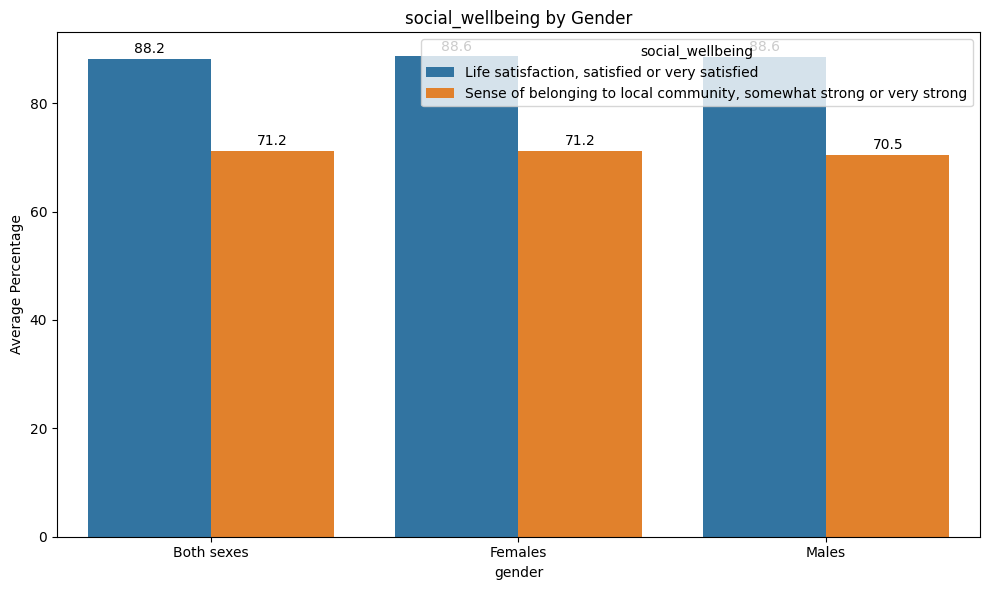

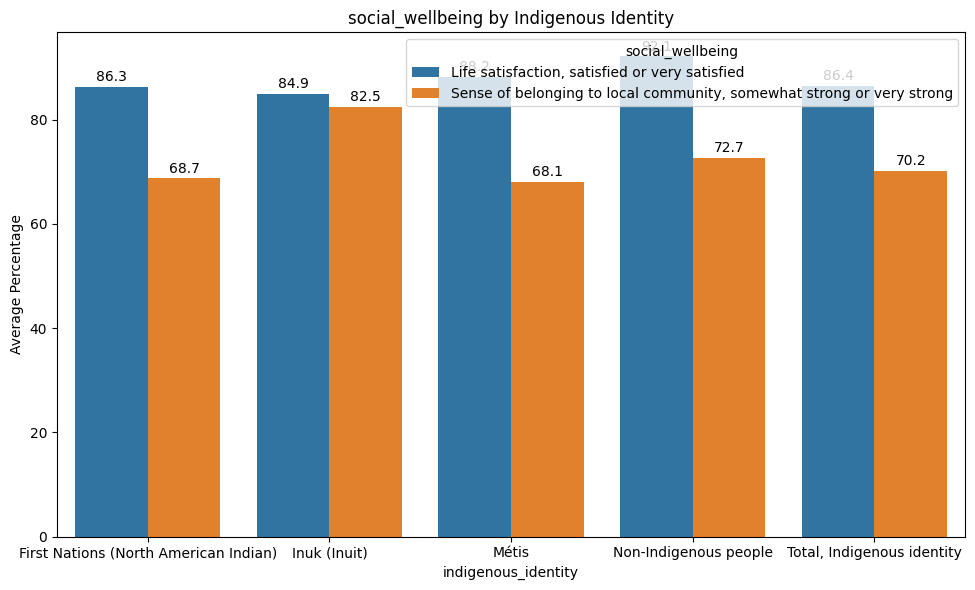

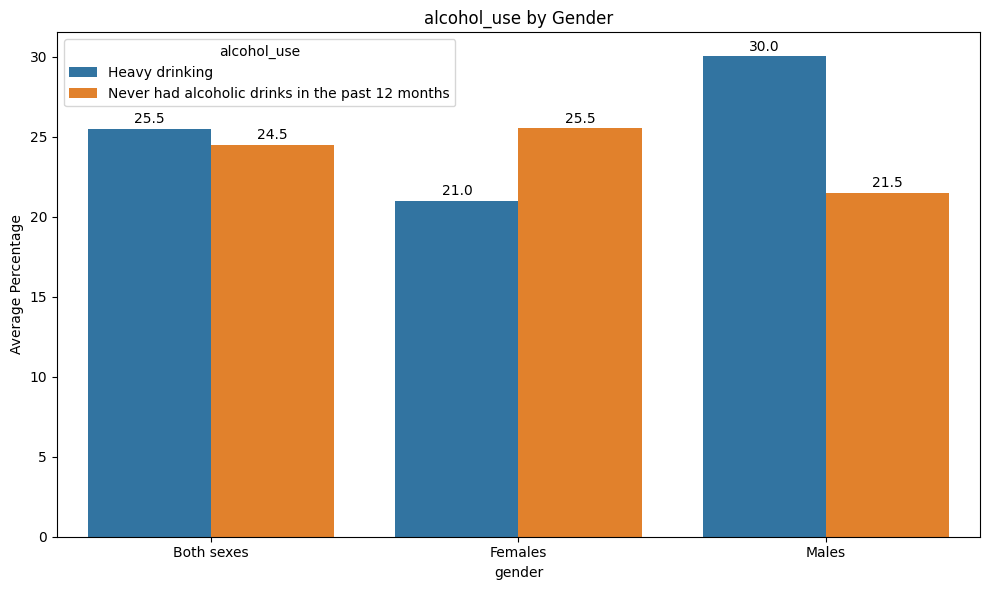

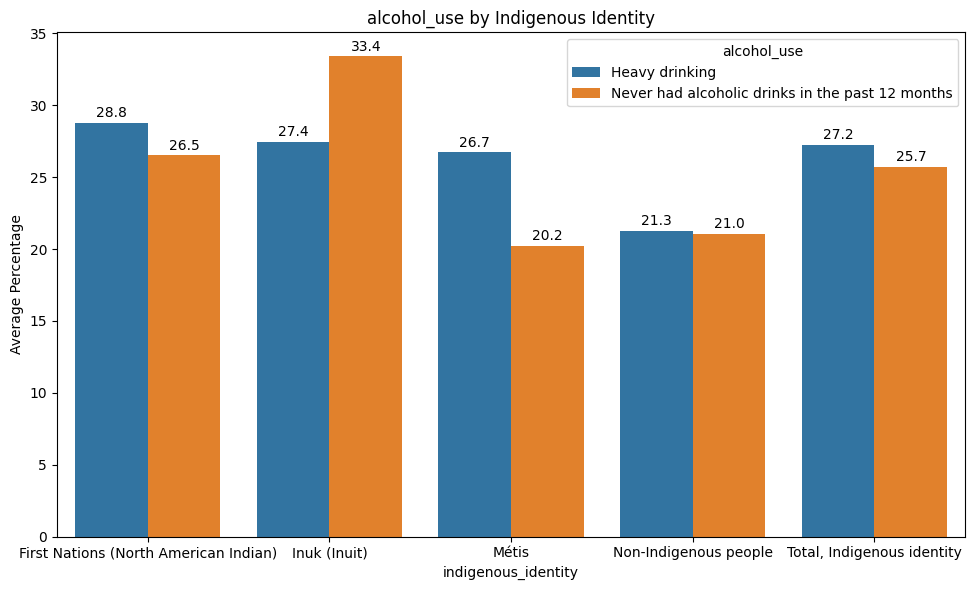

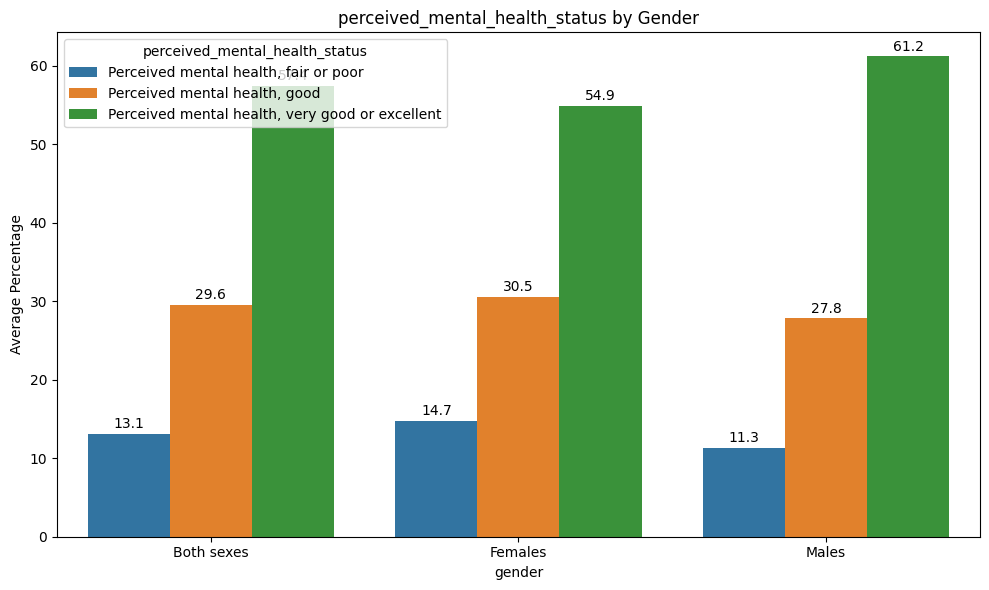

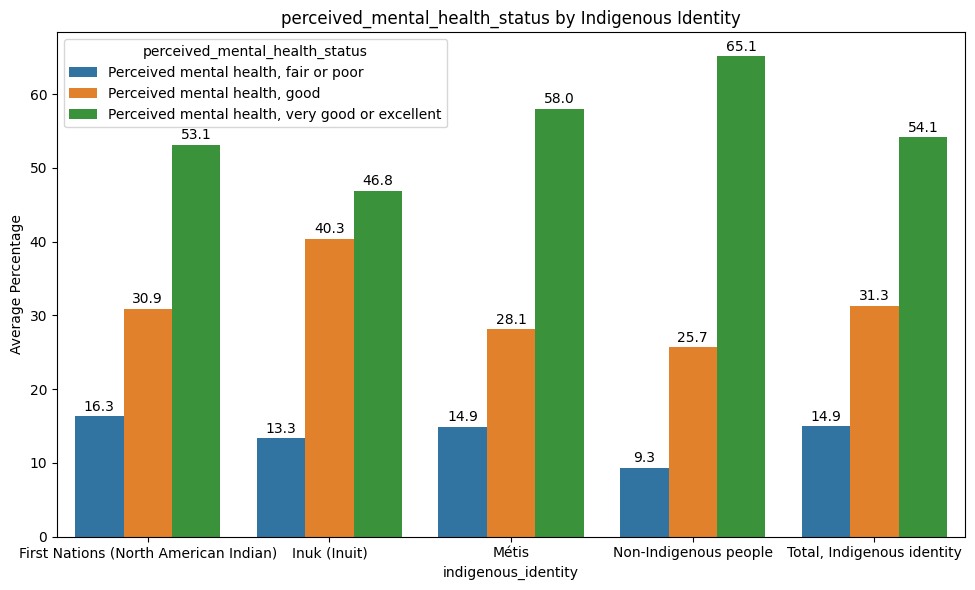

In [22]:
for col in plot_cols:
    plot_bar_chart(df, 'gender', col, col+" by Gender", stacked_by=False)
    plot_bar_chart(df, 'indigenous_identity', col, col+" by Indigenous Identity", stacked_by=False)

* Food insecurity is most common in the Inuk population, while non-indigenous people has the lowest prevalence
* While more than half of non-Indigenous people perceive their health as excellent, this percentage is below 50% for all Indigenous groups
* More than half of Inuk individuals smoke, but they also have the highest rate of never having had alcohol in the past 12 months among all Indigenous groups
* Indigenous groups tend to have higher obesity rates compared to non-Indigenous people

Overall, food insecurity and perceived health were generally worse among Indigenous groups compared to the non-Indigenous population